<a href="https://colab.research.google.com/github/donjadao/lis4693_don_jacky_final_project/blob/main/Machine_Learning_Model_Ramen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jacky Chen, Don Dao Final Project
Amazon Ramen Reviews: Machine Learning

Installing and loading libraries

In [1]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [3]:
import requests
import io

In [4]:
url = "https://raw.githubusercontent.com/donjadao/lis4693_don_jacky_final_project/main/data/ramen_reviews_long.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

A function to load all the reviews from the folder

In [5]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head())

    ProductId  Score                                          Summary  \
0  B003OB0IB8      4  Tastes great. Love Hot & Spicy. Bad price here.   
1  B003OB0IB8      5                                My favorite ramen   
2  B003OB0IB8      3                                        It burns!   
3  B003OB0IB8      5                        Amazing to the last bite.   
4  B003OB0IB8      4            Tastes great, but is cheaper locally.   

                                                Text        Time  \
0  I've been a fan of Hot & Spicy Maruchan Ramen ...  1325808000   
1  I've been eating Ramen noodles since I was a l...  1314489600   
2  I LOVE spicy ramen, but for whatever reasons t...  1329436800   
3  Always being a fan of ramen as a quick and eas...  1330473600   
4  I love this flavor of ramen! I don't eat other...  1333756800   

   HelpfulnessNumerator  HelpfulnessDenominator  
0                     4                       4  
1                     4                       4  
2 

Looking at the fields in a different format

In [6]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ProductId               1241 non-null   object
 1   Score                   1241 non-null   int64 
 2   Summary                 1241 non-null   object
 3   Text                    1241 non-null   object
 4   Time                    1241 non-null   int64 
 5   HelpfulnessNumerator    1241 non-null   int64 
 6   HelpfulnessDenominator  1241 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 68.0+ KB


,ProductId,Score,Summary,Text,Time,HelpfulnessNumerator,HelpfulnessDenominator
0,B003OB0IB8,4,Tastes great. Love Hot & Spicy. Bad price here.,I've been a fan of Hot & Spicy Maruchan Ramen ...,1325808000,4,4
1,B003OB0IB8,5,My favorite ramen,I've been eating Ramen noodles since I was a l...,1314489600,4,4
2,B003OB0IB8,3,It burns!,"I LOVE spicy ramen, but for whatever reasons t...",1329436800,3,3
3,B003OB0IB8,5,Amazing to the last bite.,Always being a fan of ramen as a quick and eas...,1330473600,1,1
4,B003OB0IB8,4,"Tastes great, but is cheaper locally.",I love this flavor of ramen! I don't eat other...,1333756800,0,0


Now we are deciding our features and targets

In [7]:
features = df['Text']
target = df['Score']

My data isn't binary, I could keep it as positive and negative reviews with 1's and 0's but I want to expand to keep the range of 1-5 start ratings.

Below we are preprocessing and splitting the data

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

Defining and training classifiers

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

# Create model objects
nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(max_iter=2000)
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

# Train all models
nb_classifier.fit(X_train_vec, y_train)
svm_classifier.fit(X_train_vec, y_train)
lr_classifier.fit(X_train_vec, y_train)
ada_classifier.fit(X_train_vec, y_train)
random_classifier.fit(X_train_vec, y_train)

print("All models trained.")

All models trained.


Generating Predictions

In [10]:
nb_predictions = nb_classifier.predict(X_test_vec)
svm_predictions = svm_classifier.predict(X_test_vec)
lr_predictions = lr_classifier.predict(X_test_vec)
ada_predictions = ada_classifier.predict(X_test_vec)
rf_predictions = random_classifier.predict(X_test_vec)

Finding Accuracy of all Classifiers

In [11]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(rf_predictions == y_test))

NB Accuracy: 0.6305220883534136
SVM Accuracy: 0.6586345381526104
LR Accuracy: 0.642570281124498
ADA Accuracy: 0.642570281124498
RF Accuracy: 0.6586345381526104


With the fact that there are 5 choices of ratings to choose from and each of the models having at least a 60% accuracy, I'd say the ppredictions are doing pretty well.

Classification Reports


In [12]:
from sklearn.metrics import classification_report

target_names_list = ['1', '2', '3', '4', '5']

print("Naive Bayes. . .")
print(classification_report(y_test, nb_predictions, target_names=target_names_list))

print("Logistic Regression. . .")
print(classification_report(y_test, lr_predictions, target_names=target_names_list))

print("AdaBoost. . .")
print(classification_report(y_test, ada_predictions, target_names=target_names_list))

print("Random Forest. . .")
print(classification_report(y_test, rf_predictions, target_names=target_names_list))

print("SVM. . .")
print(classification_report(y_test, svm_predictions, target_names=target_names_list))

Naive Bayes. . .
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       0.00      0.00      0.00        12
           3       0.00      0.00      0.00        19
           4       0.00      0.00      0.00        47
           5       0.63      1.00      0.77       157

    accuracy                           0.63       249
   macro avg       0.13      0.20      0.15       249
weighted avg       0.40      0.63      0.49       249

Logistic Regression. . .
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        14
           2       1.00      0.25      0.40        12
           3       0.00      0.00      0.00        19
           4       0.45      0.11      0.17        47
           5       0.65      0.97      0.78       157

    accuracy                           0.64       249
   macro avg       0.42      0.26      0.27       249
weighted avg       0.54      0.64  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

63% of our data are 5 star reviews, because of this, our model will be much better at indentifying 5 star reviews over lower ones. A lot of the models seems to have listed 5 start for the reviews just because. Based, on the numbers, SVM is the best choice.

SVM is the only classifier that:
- Doesn’t default to predicting only 5 star ratings
- Attempts to separate the middle classes
- Achieves non‑zero precision/recall for all classes

Grid Search for SVM

In [13]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(LinearSVC(), parameters, cv=10, verbose=1)
svm_best.fit(X_train_vec, y_train)

print("Best SVM Parameters:")
print(svm_best.best_params_)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Best SVM Parameters:
{'C': 10}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [19]:
best_svm_predictions = svm_best.predict(X_test_vec)

In [22]:
print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

print("Best SVM Classification Report. . .")
print(classification_report(y_test, best_svm_predictions, target_names=['1','2','3','4','5']))


Best SVM Accuracy: 0.6465863453815262
Best SVM Classification Report. . .
              precision    recall  f1-score   support

           1       0.50      0.21      0.30        14
           2       0.50      0.25      0.33        12
           3       0.43      0.16      0.23        19
           4       0.38      0.36      0.37        47
           5       0.73      0.86      0.79       157

    accuracy                           0.65       249
   macro avg       0.51      0.37      0.40       249
weighted avg       0.62      0.65      0.62       249



Confusion Matrix

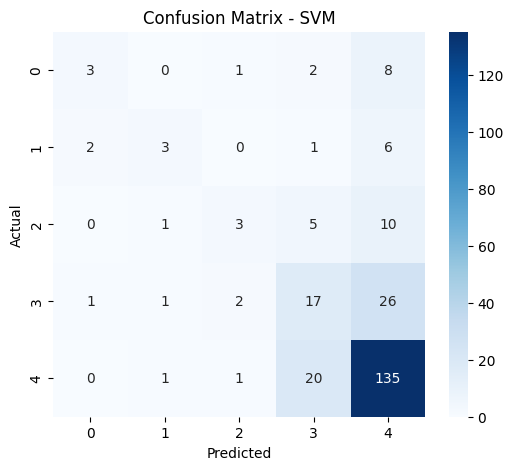

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_svm_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

Predicting New Reviews

In [31]:
fake_url = "https://raw.githubusercontent.com/donjadao/lis4693_don_jacky_final_project/main/data/RamenFakeReviews.csv?nocache=1"
fake_df = pd.read_csv(fake_url)

fake_df.head()


,Text
0,"The broth was rich and flavorful, but the nood..."
1,I loved the spicy kick in this ramen; it warme...
2,"The portion size felt small, but the taste was..."
3,"The noodles had a great chewiness, and the bro..."
4,"Way too salty for me, even after adding extra ..."


In [32]:
fake_reviews = fake_df['Text']

In [33]:
fake_vec = vectorizer.transform(fake_reviews)

In [34]:
fake_preds = svm_best.predict(fake_vec)

In [35]:
for review, label in zip(fake_reviews, fake_preds):
    print(f"Review: {review}\nPredicted Score: {label}\n")

Review: The broth was rich and flavorful, but the noodles were a little too soft for my taste.
Predicted Score: 5

Review: I loved the spicy kick in this ramen; it warmed me up instantly.
Predicted Score: 5

Review: The portion size felt small, but the taste was excellent.
Predicted Score: 5

Review: The noodles had a great chewiness, and the broth tasted homemade.
Predicted Score: 5

Review: Way too salty for me, even after adding extra water.
Predicted Score: 4

Review: The flavor packet smelled amazing and delivered a deep umami taste.
Predicted Score: 5

Review: I didn?t enjoy the texture; the noodles turned mushy too quickly.
Predicted Score: 4

Review: Surprisingly delicious for the price ? I?d buy it again.
Predicted Score: 5

Review: The spice level was perfect, not overwhelming but still exciting.
Predicted Score: 5

Review: The broth tasted bland, and I had to add my own seasoning.
Predicted Score: 2

Review: The noodles cooked evenly and held their texture well.
Predicted Sc

I would say the prediction the report generated were not the most accurate, probably about a 60% accuracy. There was only sincleentry of a 1 score and single score of 2.

End